# Gender Bias in Occupation Prediction: A BiasBios Analysis

## Project Overview
This project uses the BiasBios dataset to train a logistic regression classifier that predicts occupation from professional biography text. Beyond standard evaluation, the project includes an ethics analysis: the top-weighted TF-IDF features per occupation class are extracted from the trained model, and their correlation with ground-truth gender labels is computed. This surfaces the gendered vocabulary driving predictions, demonstrating how gender bias can persist in a model even when gender is not an explicit input feature.

## Imports & Setup

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.core.display import HTML

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from scipy.sparse import vstack
from scipy.stats import pointbiserialr

from datasets import load_dataset
from pathlib import Path

import os
import random
from enum import StrEnum

# Allow to show all columns
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# Set seaborn theme easy to read for colorblind readers
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")


In [49]:
# Globals
DATA_PATH = Path("biasbios.parquet")
NOTEBOOK_SEED = 42

In [50]:
# Ensure Reproducibility
np.random.seed(NOTEBOOK_SEED)
random.seed(NOTEBOOK_SEED)

`BiasInBiosColumns` are used to reduce typos in accessing columns in the pandas DateFrame:

In [51]:
# Description of Dataset columns

class BiasInBiosColumns(StrEnum):
    """Column names for the Bias in Bios dataset.

    Source: https://huggingface.co/datasets/LabHC/bias_in_biostrain
    License: MIT
    """

    # Core columns
    BIO = "hard_text"
    PROFESSION = "profession"
    GENDER = "gender"
    SPLIT = "split"

    # Columns added through data prep
    PROFESION_TEXT = "profesion_text"
    GENDER_TEXT = "gender_text"
    
    
class DataSplit(StrEnum):
    """Valid Values for column BiasInBiosColumns.SPLIT"""
    TRAIN = "train"
    DEV = "dev"
    TEST = "test"

VALID_SPLITS = {s.value for s in DataSplit}

In [52]:
GENDER_TO_TEXT = [
        "male",
        "female"
]

PROFESSION_TO_TEXT = [
    "accountant",
    "architect",
    "attorney",
    "chiropractor",
    "comedian",
    "composer",
    "dentist",
    "dietitian",
    "dj",
    "filmmaker",
    "interior_designer",
    "journalist",
    "model",
    "nurse",
    "painter",
    "paralegal",
    "pastor",
    "personal_trainer",
    "photographer",
    "physician",
    "poet",
    "professor",
    "psychologist",
    "rapper",
    "software_engineer",
    "surgeon",
    "teacher",
    "yoga_teacher",
]

## Load Data 

De-Areaga et al. (2019) compiled a dataset of professional biographies, along with their occupations and genders, from a web crawl. Although De-Artega et al. (2019) released the code to crawl the dataset, they didn’t release the dataset itself. Ravfogel et al. (2020) released a freely downloadable version of the crawled dataset for their own use.  The version used in this analysis is a Hugging Face Dataset upload by Laboratoire Hubert Curien, a French University. It uses the same data and training/dev/test splits as Ravfogel et al. (2020). It should be noted that the Ravfogel et al. (2020) version has 396,189 datapoints, which is slightly smaller than the De-Artega et al. (2019) version, as 5,557 biographies were no longer available on OpenCrawl. The analysis combines the four splits into a single parquet file and adds a split column to maintain consistency with the original data. 

Automatically download dataset if it does not exist. In any case `biasbios_df` will contain a pandas DataFrame with Bias Bios Dataset: 

In [53]:
def download_bias_in_bios(data_path: Path):
    """Download bias_in_bios dataset and save to CSV.
    
    Args:
        data_path: Path object where CSV will be written.
        
    Raises:
        AssertionError: If load_dataset().to_pandas() returns non-DataFrame.
    """
     
    dfs : list[pd.DataFrame] = []
    for split in VALID_SPLITS:
        df = load_dataset("LabHC/bias_in_bios", split=split).to_pandas()

        # can return an iterator but it shouldn't assert corrrectness 
        assert isinstance(df, pd.DataFrame), "Incorrect Dataset"
        df[BiasInBiosColumns.SPLIT] = split
        dfs.append(df)
    
    full_df = pd.concat(dfs, ignore_index=True, axis=0) 
    assert isinstance(full_df, pd.DataFrame), "Incorrect Dataset"
    # create CSV 
    data_path.parent.mkdir(parents=True, exist_ok=True)
    full_df.to_parquet(data_path) 

def load_and_cache_data(data_path: Path) -> pd.DataFrame:

    """Load bias_in_bios dataset, downloading and caching if necessary.

    Args:
        data_path: Path where cached CSV is/will be stored.

    Returns:
        DataFrame with bias_in_bios data and split column.
    """
    if not data_path.exists():
        download_bias_in_bios(data_path)

    return pd.read_parquet(data_path)

In [54]:
biasbios_df = load_and_cache_data(DATA_PATH)

A quick check on the data gives a first glimps into the dataset: 

In [55]:
biasbios_df.head()

,hard_text,profession,gender,split
0,"He specializes in development economics, house...",21,0,test
1,He started out as a DJ and music producer in t...,5,0,test
2,"She is averse to all things scary or sad, so s...",4,1,test
3,"Prior to joining USC, she was a mobile news ed...",21,1,test
4,"Previously, she served as an assistant profess...",21,1,test


In [56]:
biasbios_df.shape

(396189, 4)

In [57]:
biasbios_df.dtypes

hard_text       str
profession    int64
gender        int64
split           str
dtype: object

The size of the dataset are 396,189 rows and 34 columns. The columns in the dataset are `hard_text` as string, containing the biographies; `profession` as integer, containing the occupation; `gender`, containing the gender of the professional as integer; and `split` as string, containing “dev”, “train”, or “dev” depending on the data split from the original. The dev (development) set is a held-out split used to tune model hyperparameters during training, keeping the test set unseen until final evaluation. The profession and gender are categorical variables encoded as integers, as can be seen here: 

In [58]:
biasbios_df[BiasInBiosColumns.PROFESSION].value_counts().sort_index()

profession
0       5633
1      10108
2      32570
3       2655
4       2809
5       5599
6      14585
7       3952
8       1486
9       6996
10      1461
11     19941
12      7491
13     18950
14      7734
15      1765
16      2523
17      1430
18     24269
19     40998
20      7014
21    118076
22     18380
23      1403
24      6912
25     13587
26     16203
27      1659
Name: count, dtype: int64

In [59]:
biasbios_df[BiasInBiosColumns.GENDER].value_counts().sort_index()

gender
0    213543
1    182646
Name: count, dtype: int64

Having integer values will hamper interpretations which is an ovious data quality issue that needs to be dealt with. 

## Data Preparation

### Check for missing values

In [60]:
biasbios_df.isnull().sum()

hard_text     0
profession    0
gender        0
split         0
dtype: int64

No missing values in this data, so no need to clean null values.

### Decoding Categorical Values

Although having integer values for “gender” and “professional” aids in training, it hampers interpretation. Therefore, during data cleaning, two columns were added: “profession_text” and “gender_text,” which contain textual representations of profession and gender, respectively:

In [61]:
def add_textual_representations(df: pd.DataFrame) -> pd.DataFrame:
    """ Adds textual representations for gender and profession 

    Args: 
        df: BiasBios Dataset 

    Return: 
        pd.DataFrame: copy of the original dataframe with textual represenations of gender as "gender_text" and "profession_text".
        
    """ 

    df = df.copy()
    df[BiasInBiosColumns.GENDER_TEXT] = df[BiasInBiosColumns.GENDER].map(lambda x: GENDER_TO_TEXT[x])
    df[BiasInBiosColumns.PROFESION_TEXT] = df[BiasInBiosColumns.PROFESSION].map(lambda x: PROFESSION_TO_TEXT[x])
    return df 

biasbios_df = add_textual_representations(biasbios_df)

Here is a sanity check that the addition worked: 

In [62]:
biasbios_df.head()

,hard_text,profession,gender,split,gender_text,profesion_text
0,"He specializes in development economics, house...",21,0,test,male,professor
1,He started out as a DJ and music producer in t...,5,0,test,male,composer
2,"She is averse to all things scary or sad, so s...",4,1,test,female,comedian
3,"Prior to joining USC, she was a mobile news ed...",21,1,test,female,professor
4,"Previously, she served as an assistant profess...",21,1,test,female,professor


## Feature Engineering

Before going into the feature engineering, the datsaet is split into a trianing, dev and test set. To keep it in sync with the plethora of resarch, it is split in the same manneer as Ravfogel et. al (2020) did:

In [63]:
train_df = biasbios_df[biasbios_df[BiasInBiosColumns.SPLIT] == DataSplit.TRAIN]
dev_df = biasbios_df[biasbios_df[BiasInBiosColumns.SPLIT] == DataSplit.DEV]
test_df = biasbios_df[biasbios_df[BiasInBiosColumns.SPLIT] == DataSplit.TEST]

First it's necessary to turn the biographies into a numerical vector. In this analysis a standard classical NLP method is used: TF-IDF. This splits the text into words, counts the word frequency (TF), and downweights terms that appear across most documents (IDF: inverse document frequency). Terms appearing in more than 99% of documents are excluded entirely. Stopword removal is deliberately skipped to preserve explicit gender indicators such as 'he' and 'she', which are central to the ethics analysis. Log normalisation is applied to raw term frequency to reduce the dominance of repetitive terms. It is fitted on the train dataset only to prevent data leakage: 

In [64]:
tf_idf = TfidfVectorizer(
    analyzer="word",
    lowercase=True,
    stop_words=None,
    ngram_range=(1, 1),
    max_features=50_000,
    min_df=0.001,
    max_df=0.99,
    sublinear_tf=True,
)
tf_idf = tf_idf.fit(train_df[BiasInBiosColumns.BIO])


Next the biography text is vectorized for each split, producing a sparse matrix of biography vectors. The sparse format is preserved throughout to avoid the memory cost of dense conversion, which at 50k features and 99k test documents would require approximately 20GB:

In [79]:
X_train = tf_idf.transform(train_df[BiasInBiosColumns.BIO])
X_dev = tf_idf.transform(dev_df[BiasInBiosColumns.BIO])
X_test = tf_idf.transform(test_df[BiasInBiosColumns.BIO])

The target labels are the integer profession codes, which sklearn accepts directly without further encoding:

In [ ]:
y_train = train_df[BiasInBiosColumns.PROFESSION]
y_dev = dev_df[BiasInBiosColumns.PROFESSION]
y_test = test_df[BiasInBiosColumns.PROFESSION]

## Training A Profession Classifier Based On Bio Text

### Defining A Baseline
Before training the actual classifier, it is prudent to understand the correct baseline. One of the simplest and most effective baselines is to predict the most common class of professions:

In [84]:
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)
y_baseline = baseline.predict(X_test)

print(
    classification_report(
        y_test, y_baseline, target_names=PROFESSION_TO_TEXT, zero_division=0)
)

                   precision    recall  f1-score   support

       accountant       0.00      0.00      0.00      1409
        architect       0.00      0.00      0.00      2528
         attorney       0.00      0.00      0.00      8143
     chiropractor       0.00      0.00      0.00       664
         comedian       0.00      0.00      0.00       703
         composer       0.00      0.00      0.00      1401
          dentist       0.00      0.00      0.00      3647
        dietitian       0.00      0.00      0.00       989
               dj       0.00      0.00      0.00       372
        filmmaker       0.00      0.00      0.00      1750
interior_designer       0.00      0.00      0.00       366
       journalist       0.00      0.00      0.00      4986
            model       0.00      0.00      0.00      1874
            nurse       0.00      0.00      0.00      4738
          painter       0.00      0.00      0.00      1935
        paralegal       0.00      0.00      0.00       

The baseline is justified by these numbers over a simpler approach such as using a discrete uniform distribution. There are 28 professions, so random guessing would yield an accuracy of 1/28 ~= 3.57%. In the case of predicting the most frequent class, the baseline yields 30% accuracy. The exact macro averages and weighted averages will be discussed against the actual model later.

What is interesting, however, is the predominance of professors in the dataset. 30% of all bios were professor bios. This over-representation of professors is due to the methodology of using a web crawl, as academic bios are far more common online.

## Training the Profession Classifier Model
For this project a logistic regression classifier was chosen. The motivation is to show that it is fast and simple to train and easier to interpret compared to more complex models such as neural networks. It is this interpretability that will be used later in this notebook to investigate whether the model learned a bias. However, interpretability comes at a price. Its expressiveness is severely limited both by its linearity and parameter count. So the very thing that makes it fast and interpretable also makes it worse on most problems compared to modern deep learning.

Before training the profession classifier, hyperparameters need to be set. In logistic regression, most hyperparameters have sensible defaults that work well without tuning. The exception is the C parameter, which is an inverse regularisation term: smaller values mean stronger regularisation, while very large values approach no regularisation at all. Because C directly controls the bias-variance tradeoff and is sensitive to the scale of the feature space, it warrants a dedicated search.

It is good practice to use a hyperparameter search to find the best value. Grid search is a good candidate when training cost is not prohibitively long and the order of magnitude matters more than the precise value. Both conditions hold here. However, to avoid tuning the hyperparameters to the test set, a separate dev set is used. Ravfogel et al. (2020) have already defined one as part of their original split:

In [ ]:
split = PredefinedSplit([-1] * X_train.shape[0] + [0] * X_dev.shape[0])
X_traindev = vstack([X_train, X_dev])
y_traindev = pd.concat([y_train, y_dev]).reset_index(drop=True)

gs = GridSearchCV(
    LogisticRegression(
        solver="lbfgs",
        max_iter=1000,
        class_weight="balanced",
    ),
    param_grid={"C": [0.01, 0.1, 1.0, 10.0]},
    cv=split,
    scoring="f1_macro",
)
gs.fit(X_traindev, y_traindev)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","PredefinedSpl...pe=(297120,)))"
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- 

In [69]:
gs.best_params_

{'C': 1.0}

The grid search identified C=1.0 as the best value. Using this, the logistic regression is trained with the lbfgs solver for a maximum of 1000 iterations, stopping early if convergence is reached. It is important to note that balanced class weighting is used. This downweights the loss contribution of majority classes and upweights minority classes, which reduces overall accuracy but produces more meaningful predictions across all 28 professions. Given the strong overrepresentation of professors in this dataset, balanced weighting prevents the model from defaulting to majority-class predictions at the expense of rarer occupations:

In [70]:
model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    C=1.0,
    class_weight="balanced",
)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [ ]:


y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=PROFESSION_TO_TEXT))


0.761216929614713
                   precision    recall  f1-score   support

       accountant       0.56      0.78      0.66      1409
        architect       0.59      0.65      0.62      2528
         attorney       0.89      0.83      0.86      8143
     chiropractor       0.47      0.84      0.60       664
         comedian       0.51      0.78      0.62       703
         composer       0.70      0.85      0.77      1401
          dentist       0.93      0.92      0.93      3647
        dietitian       0.66      0.86      0.75       989
               dj       0.44      0.72      0.55       372
        filmmaker       0.70      0.82      0.75      1750
interior_designer       0.37      0.73      0.49       366
       journalist       0.69      0.73      0.71      4986
            model       0.67      0.79      0.72      1874
            nurse       0.81      0.83      0.82      4738
          painter       0.69      0.85      0.76      1935
        paralegal       0.45      0.7

In [73]:
model.get_params()

{'C': 1.0,
 'class_weight': 'balanced',
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 1000,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [74]:
model.coef_[0, :]

array([ 0.59063864,  0.95301289, -0.27269139, ..., -0.15306521,
       -0.02586129,  0.32061818], shape=(4402,))

In [75]:
def calculate_correlations_to_gender(model,tf_idf, X_test, test_df, top_n, top_k):
    indices = np.argsort(model.coef_,  axis=1)[:, -top_n:]
    X_test_dense = X_test.toarray()

    correlations = np.zeros((28, top_n))
    p_values = np.zeros((28, top_n))

    for class_idx in range(28):
        for feat_idx in range(top_n):
            col_idx = indices[class_idx, feat_idx]
            feature = X_test_dense[:, col_idx]

            corr, pval = pointbiserialr(test_df["gender"], feature)
            correlations[class_idx, feat_idx] = corr
            p_values[class_idx, feat_idx] = pval
    corr_sorted_idx = np.argsort(np.abs(correlations), axis=1)[:, ::-1][:, :top_k]
    idx = indices[
        np.arange(28)[:, None], corr_sorted_idx
    ]
    feature_names = tf_idf.get_feature_names_out()
    top_k_correlations = correlations[np.arange(28)[:, None], corr_sorted_idx]
    top_k_features =  feature_names[idx]
    corr_features = np.hstack((top_k_correlations, top_k_features))
    column_names = [f"top_{k}_correlation" for k in range(top_k)] + [
        f"top_{k}_feature" for k in range(top_k)
    ]
    result_df = pd.DataFrame(corr_features, columns=column_names)
    result_df["profession"] = PROFESSION_TO_TEXT
    return result_df

result_df = calculate_correlations_to_gender(
    model, tf_idf, X_test, test_df, 25, 3
)


In [76]:
result_df.sort_values("top_0_correlation",ascending=False)[["profession", "top_0_feature", "top_1_feature", "top_2_feature"]]


,profession,top_0_feature,top_1_feature,top_2_feature
27,yoga_teacher,she,students,yoga
12,model,she,freeones,born
26,teacher,she,ms,children
7,dietitian,she,nutrition,health
13,nurse,she,ms,nurse
10,interior_designer,her,home,design
2,attorney,ms,mr,issues
19,physician,ms,specializes,dr
21,professor,nursing,dr,book
20,poet,english,performed,writing


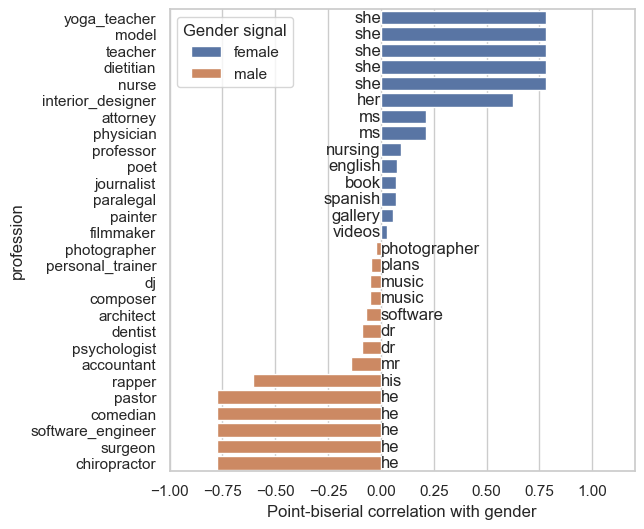

In [77]:
def plot_gender_correlations(df, save_to=None):
    df = df.sort_values("top_0_correlation",ascending=False).reset_index()
    df["gender_signal"] = df["top_0_correlation"].map(lambda x: "female" if x >= 0 else "male")
    plt.figure(figsize=(6, 6))
    ax = sns.barplot(df, x="top_0_correlation", y="profession", orient="h", hue="gender_signal")
    for i, (_, row) in enumerate(df.iterrows()):
        ax.text(0, i, row["top_0_feature"],va="center", ha="right" if df["top_0_correlation"][i] >= 0 else "left")
    plt.legend(title="Gender signal")
    plt.xlabel("Point-biserial correlation with gender")
    plt.xlim(-1.0, 1.2)
    if save_to:
        plt.savefig(save_to, bbox_inches="tight", dpi=150)
plot_gender_correlations(result_df, "report/figures/gender_bias_correlation.png")